In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')

In [3]:
test = pd.read_csv('test.csv')

In [4]:
data = pd.concat([train, test], axis=0, ignore_index=True)

In [5]:
data['fuel_type'].value_counts()

fuel_type
Gasoline          276473
Hybrid             11508
E85 Flex Fuel       8929
Diesel              6641
–                   1319
Plug-In Hybrid       858
not supported         29
Name: count, dtype: int64

In [6]:
data['is_gasoline'] = (data['fuel_type'] == 'Gasoline').astype(int)

In [7]:
data_engine_electric = data[data['fuel_type'].isna()][['engine', 'fuel_type']]

In [8]:
data_engine_electric

,engine,fuel_type
11,Electric Motor Electric Fuel System,NaN
32,518.0HP Electric Motor Electric Fuel System,NaN
51,Dual Motor - Standard,NaN
52,518.0HP Electric Motor Electric Fuel System,NaN
161,670.0HP Electric Motor Electric Fuel System,NaN
...,...,...
313955,835.0HP Electric Motor Electric Fuel System,NaN
314063,271.0HP Electric Motor Electric Fuel System,NaN
314201,518.0HP Electric Motor Electric Fuel System,NaN
314210,Electric Motor Electric Fuel System,NaN


In [ ]:
data['Electrical'] = (
    data['engine'].str.contains('Electric', case=False, na=False) |
    data['brand'].str.contains('Tesla', case=False, na=False) |
    data['model'].str.contains('LONG RANGE|P100D|RECHARGE|PURE ELECTRIC', case=False, na=False)
).astype(int)

In [10]:
data['Electrical'].value_counts()

Electrical
0    295475
1     18748
Name: count, dtype: int64

In [11]:
data[data['Electrical'] == 1][['engine', 'fuel_type']].isna().sum()

engine          0
fuel_type    8263
dtype: int64

In [12]:
data.loc[
    (data['fuel_type'].isna()) & (data['Electrical'] == 1),
    'fuel_type'
] = 'Electric'

In [13]:
data['fuel_type'].isna().sum()

203

In [14]:
data[data['fuel_type'].isna()][['engine', 'fuel_type']]

,engine,fuel_type
3286,70.0HP 1.0L 3 Cylinder Engine Gasoline Fuel,NaN
6794,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,NaN
8879,2.0 Liter TFSI,NaN
8908,453.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,NaN
9522,1.6L I4 16V GDI DOHC Turbo,NaN
...,...,...
308633,276.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,NaN
310616,261.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,NaN
312225,414.0HP 4.0L Flat 6 Cylinder Engine Gasoline Fuel,NaN
312319,5.0L V8 32V PDI DOHC,NaN


In [15]:
data['fuel_type'].value_counts()

fuel_type
Gasoline          276473
Hybrid             11508
E85 Flex Fuel       8929
Electric            8263
Diesel              6641
–                   1319
Plug-In Hybrid       858
not supported         29
Name: count, dtype: int64

In [16]:
data.isna().sum()

id                   0
brand                0
model                0
model_year           0
milage               0
fuel_type          203
engine               0
transmission         0
ext_col              0
int_col              0
accident          4084
clean_title      35658
price           125690
is_gasoline          0
Electrical           0
dtype: int64

In [17]:
data.loc[
    (data['fuel_type'].isna()) & (data['engine'].str.contains('Gasoline',case=False,na=False)),
    'fuel_type'
] = 'Gasoline'

In [18]:
data['fuel_type'].isna().sum()

129

In [25]:
data[data['fuel_type']=='-'][['engine', 'fuel_type']].value_counts()

Series([], Name: count, dtype: int64)

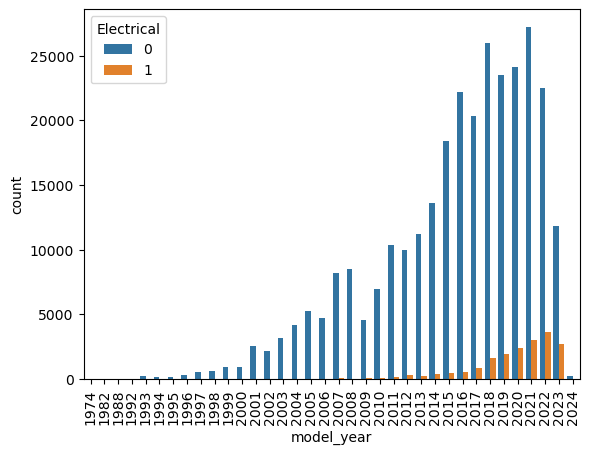

In [20]:
sns.countplot(data=data, x='model_year', hue='Electrical')
plt.xticks(rotation=90)
plt.show()

In [21]:
data[(data['fuel_type'].isna() & data['engine'].str.contains('Diesel', case=False, na=False))][['engine', 'fuel_type']]

,engine,fuel_type
47303,277.0HP 3.0L Straight 6 Cylinder Engine Diesel...,NaN
171080,3.0L I6 24V DDI DOHC Turbo Diesel,NaN
286053,6.7L V8 32V DDI OHV Turbo Diesel,NaN


In [22]:
data.loc[
    (data['fuel_type'].isna()) & (data['engine'].str.contains('Diesel',case=False,na=False)),
    'fuel_type'
] = 'Diesel'

In [27]:
data.loc[
    (data['fuel_type'].isna()),
    'fuel_type'
] = 'Gasoline'

In [28]:
data['fuel_type'].isna().sum()

0

In [29]:
data['accident'].value_counts()

accident
None reported                             240777
At least 1 accident or damage reported     69362
Name: count, dtype: int64

In [30]:
data[['accident', 'clean_title']]

,accident,clean_title
0,None reported,Yes
1,At least 1 accident or damage reported,Yes
2,None reported,Yes
3,None reported,Yes
4,None reported,Yes
...,...,...
314218,None reported,Yes
314219,None reported,NaN
314220,None reported,Yes
314221,None reported,Yes


In [31]:
data['clean_title_filled'] = data['clean_title'].fillna('Unknown')

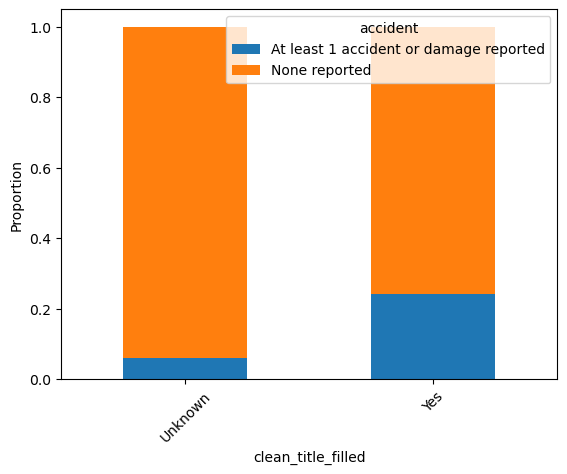

In [32]:
prop = pd.crosstab(
    data['clean_title_filled'],
    data['accident'],
    normalize='index'
)

prop.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

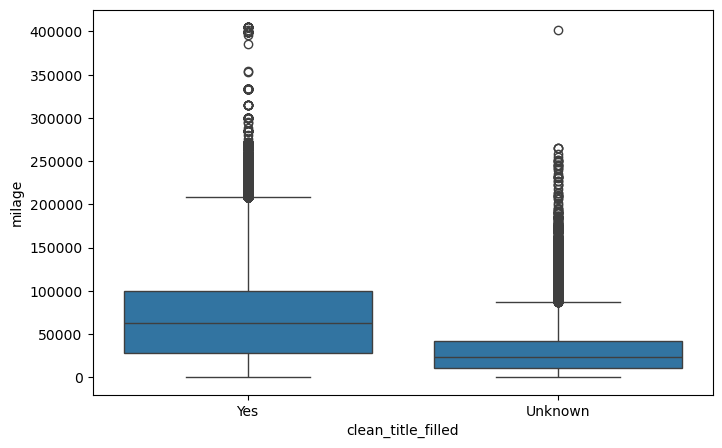

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='clean_title_filled', y='milage')
plt.show()

In [34]:
data.groupby('clean_title_filled')['price'].mean()

clean_title_filled
Unknown    63567.566273
Yes        41354.406704
Name: price, dtype: float64

In [35]:
data.isna().sum()

id                         0
brand                      0
model                      0
model_year                 0
milage                     0
fuel_type                  0
engine                     0
transmission               0
ext_col                    0
int_col                    0
accident                4084
clean_title            35658
price                 125690
is_gasoline                0
Electrical                 0
clean_title_filled         0
dtype: int64

In [36]:
data[data['accident'].isna()][['accident', 'clean_title_filled']]

,accident,clean_title_filled
87,NaN,Unknown
134,NaN,Unknown
164,NaN,Unknown
333,NaN,Unknown
361,NaN,Unknown
...,...,...
313559,NaN,Unknown
313883,NaN,Unknown
313928,NaN,Unknown
313957,NaN,Unknown


C:\Users\Pc\AppData\Local\Temp\ipykernel_20400\501586328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


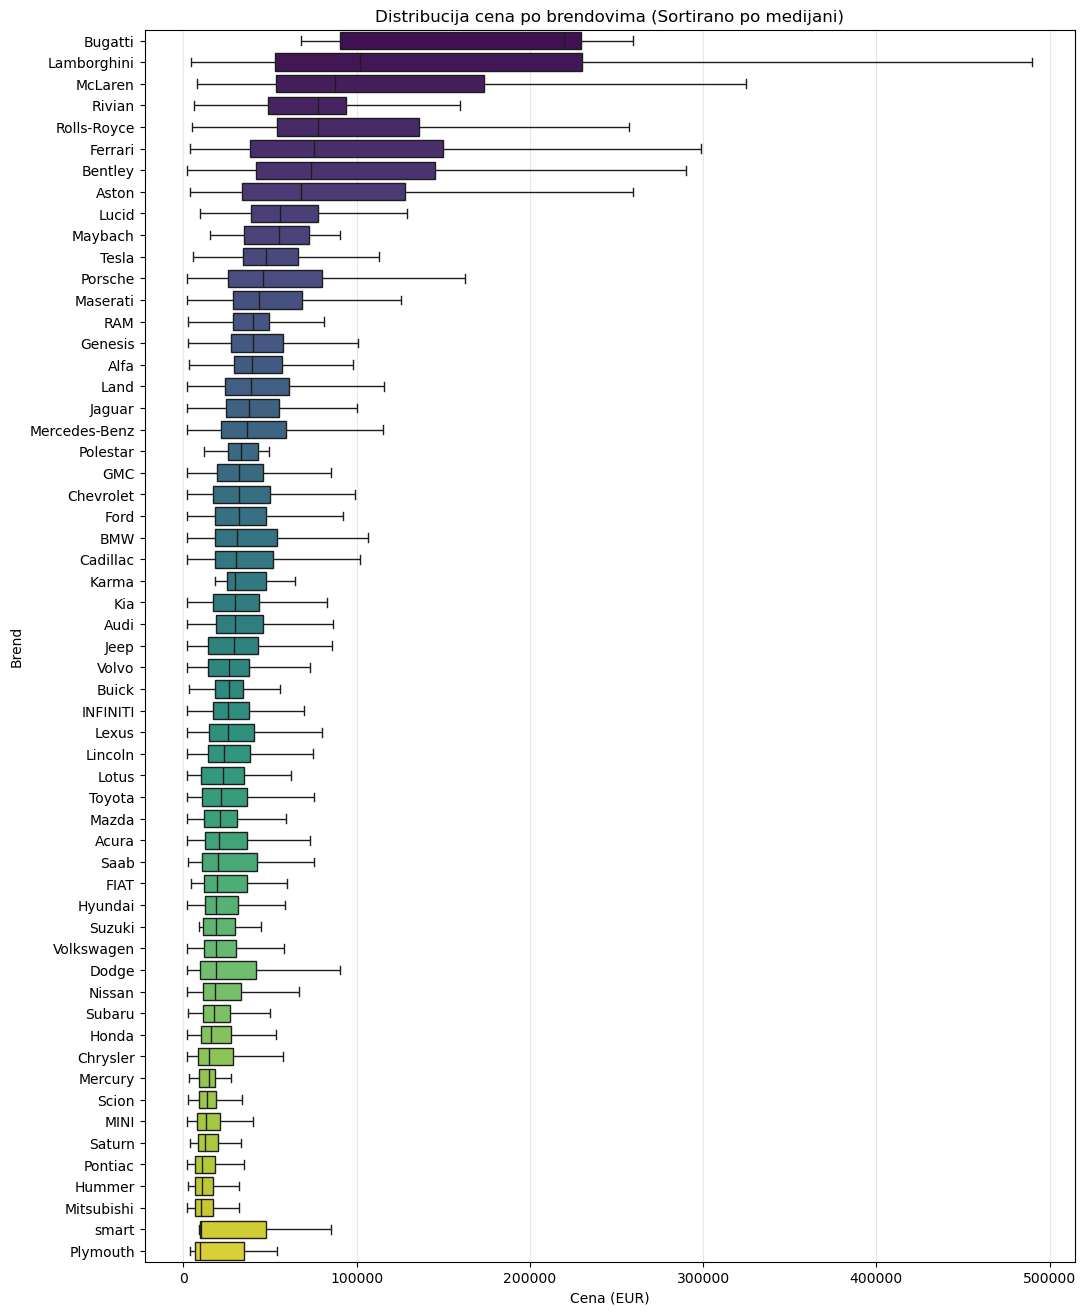

In [37]:
# Sortiramo brendove po srednjoj ceni (medijani) za preglednost
order = data.groupby('brand')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 16)) # Velika visina zbog 57 kategorija

sns.boxplot(
    data=data, 
    x='price', 
    y='brand', 
    order=order, 
    palette='viridis',
    showfliers=False # Isključujemo ekstremne vrednosti radi bolje skale
)

plt.title('Distribucija cena po brendovima (Sortirano po medijani)')
plt.xlabel('Cena (EUR)')
plt.ylabel('Brend')
plt.grid(axis='x', alpha=0.3)

plt.show()

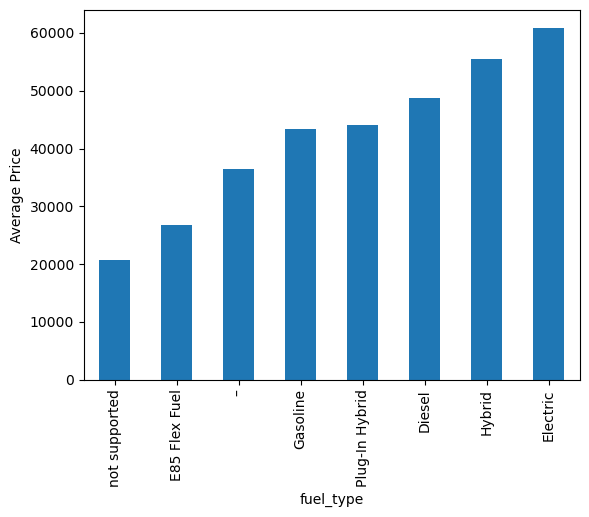

In [39]:
data.groupby('fuel_type')['price'].mean().sort_values().plot(kind='bar')
plt.ylabel('Average Price')
plt.show()

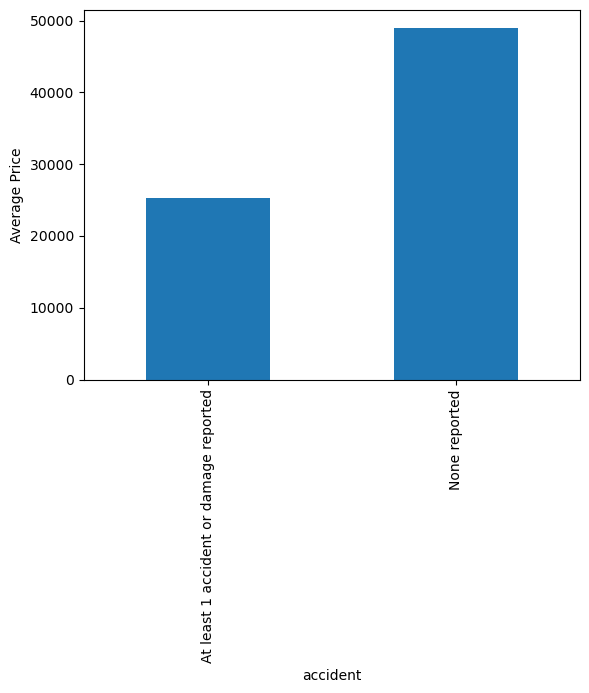

In [45]:
data.groupby('accident')['price'].mean().sort_values().plot(kind='bar')
plt.ylabel('Average Price')
plt.show()

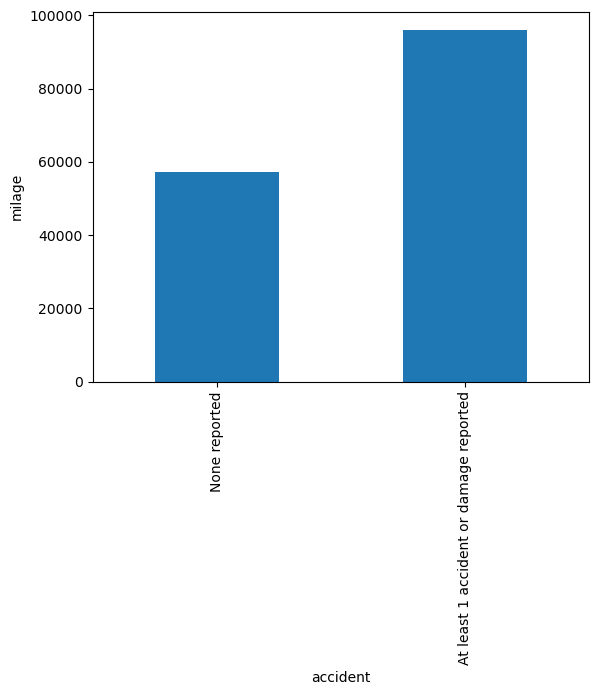

In [46]:
data.groupby('accident')['milage'].mean().sort_values().plot(kind='bar')
plt.ylabel('milage')
plt.show()

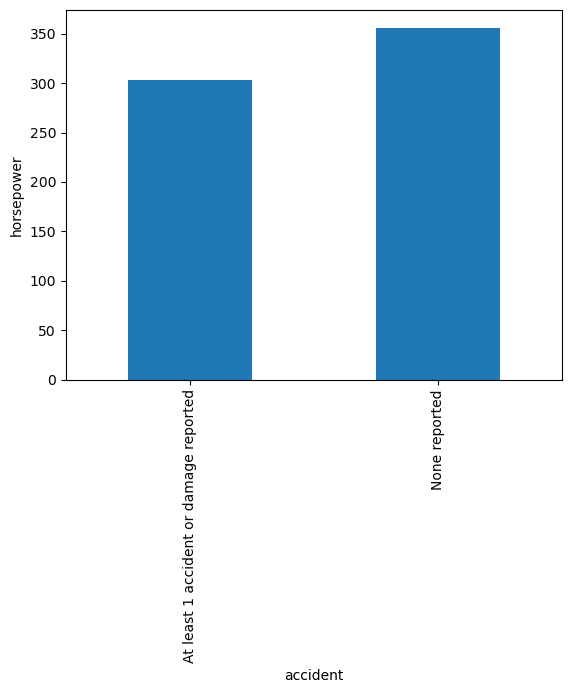

In [51]:
data.groupby('accident')['horsepower'].mean().sort_values().plot(kind='bar')
plt.ylabel('horsepower')
plt.show()

In [48]:
data['horsepower'] = data['engine'].str.extract(r'(\d+\.?\d*)HP')[0].astype(float)

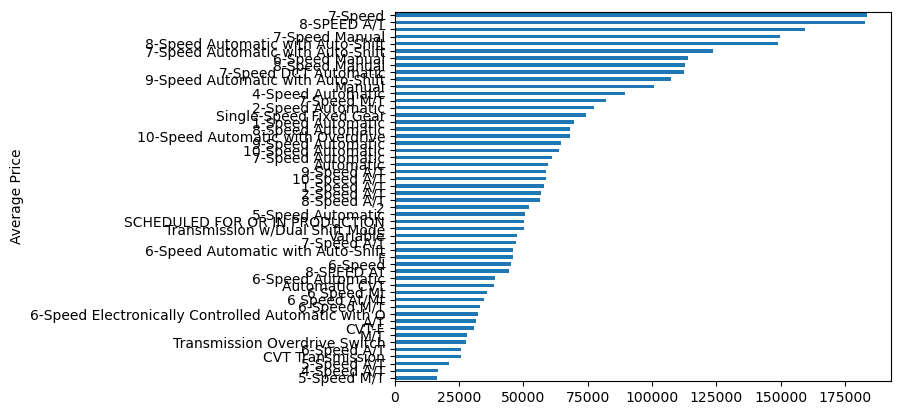

In [55]:
data.groupby('transmission')['price'].mean().sort_values().plot(kind='barh')
plt.ylabel('Average Price')
plt.show()

In [56]:
data

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,is_gasoline,Electrical,clean_title_filled,horsepower
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200.0,1,0,Yes,172.0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999.0,1,0,Yes,252.0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900.0,0,0,Yes,320.0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000.0,1,0,Yes,420.0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500.0,1,0,Yes,208.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314218,314218,Mercedes-Benz,GL-Class GL 450 4MATIC,2014,83315,Gasoline,362.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes,NaN,1,0,Yes,362.0
314219,314219,Audi,Q7 55 Prestige,2019,29336,Gasoline,3.0 Liter Turbo,Automatic,White,Black,None reported,NaN,NaN,1,0,Unknown,NaN
314220,314220,Audi,A6 3.0T Premium Plus,2012,77634,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,NaN,1,0,Yes,333.0
314221,314221,Audi,Q7 3.0T Premium,2012,112000,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,NaN,1,0,Yes,333.0
